# Tutorial: Introduction to DNABERT2
### *From Raw DNA to State-of-the-Art Foundation Models*

This tutorial demonstrates how to use the `genomics` module to process, featurize, and model genomic sequences using DeepChem's standard MolNet architecture.

We will use the **Human Non-TATA Promoters** dataset from Genomic Benchmarks to walk through a complete research workflow.


In [ ]:
!pip uninstall -y deepchem
!pip install transformers datasets accelerate

In [ ]:
!pip install -q genomic-benchmarks torch scikit-learn matplotlib deepchem

!git clone https://github.com/hanara2112/genomic_benchmark.git
%cd genomic_benchmark

!pip install -e .


In [3]:
!git pull

Already up to date.


In [ ]:
import os
import deepchem as dc
import numpy as np
import matplotlib.pyplot as plt
from genomics.loader import load_genomic_benchmark
from genomics.featurizers import DNAKmerCountFeaturizer, DNAOneHotFeaturizer
from sklearn.ensemble import RandomForestClassifier

# Set random seeds for reproducibility
np.random.seed(42)


## Section 1: Standardized Data Loading
DeepChem's `load_genomic_benchmark` function handles downloading, splitting, and memory-efficient storage.

We use `splitter="official"` to ensure we use the benchmark's standardized Train/Test sets, which is critical for scientific reproducibility.


In [4]:
# Load the dataset using the official benchmark splits
tasks, datasets, transformers = load_genomic_benchmark(
    dataset_name="human_nontata_promoters",
    featurizer="raw",    # Load raw sequences first
    splitter="official",
    reload=False
)

# Some benchmarks might only have Train/Test (Valid may be empty)
train, test = datasets[0], datasets[-1]

print(f"Tasks: {tasks}")
print(f"Train samples: {len(train)}")
print(f"Test samples:  {len(test)}")
print(f"\nSample DNA sequence: {train.X[0][:50]}...")


/usr/local/lib/python3.12/dist-packages/genomic_benchmarks/utils/datasets.py:50: UserWarning: No version specified. Using version 0.
  warnings.warn(f"No version specified. Using version {metadata['version']}.")


Tasks: ['negative', 'positive']
Train samples: 27097
Test samples:  9034

Sample DNA sequence: TCGGCCTGCGGACTCTTCCGGCCCGAACTTCTCTTACCTACCCCGCGCTC...


## Section 2: Flexible DNA Featurization
Genomic sequences need to be converted into numerical tensors. DeepChem makes this effortless.

1. **One-Hot Encoding**: Best for CNNs.
2. **K-mer Frequency**: Best for traditional ML and Transformers.


In [5]:
# 1. One-Hot Featurization (Shortcut: "onehot")
_, oh_datasets, _ = load_genomic_benchmark(
    dataset_name="human_nontata_promoters",
    featurizer="onehot",
    splitter="official",
    reload=False
)
oh_train = oh_datasets[0]
print(f"One-Hot Shape: {oh_train.X.shape} (N, Length, 4)")

# 2. K-mer Featurization (Using 4-mers)
kmer_feat = DNAKmerCountFeaturizer(k=4)
_, kmer_datasets, _ = load_genomic_benchmark(
    dataset_name="human_nontata_promoters",
    featurizer=kmer_feat,
    splitter="official",
    reload=False
)
kmer_train = kmer_datasets[0]
print(f"K-mer Shape: {kmer_train.X.shape} (N, 256 frequencies)")


/usr/local/lib/python3.12/dist-packages/genomic_benchmarks/utils/datasets.py:50: UserWarning: No version specified. Using version 0.
  warnings.warn(f"No version specified. Using version {metadata['version']}.")


One-Hot Shape: (27097, 2048, 4) (N, Length, 4)


/usr/local/lib/python3.12/dist-packages/genomic_benchmarks/utils/datasets.py:50: UserWarning: No version specified. Using version 0.
  warnings.warn(f"No version specified. Using version {metadata['version']}.")


K-mer Shape: (27097, 256) (N, 256 frequencies)


## Section 3: Data Visualization
Understanding the "signal" in your genomic data. Let's visualize the 4-mer frequency distribution between promoters and non-promoters.


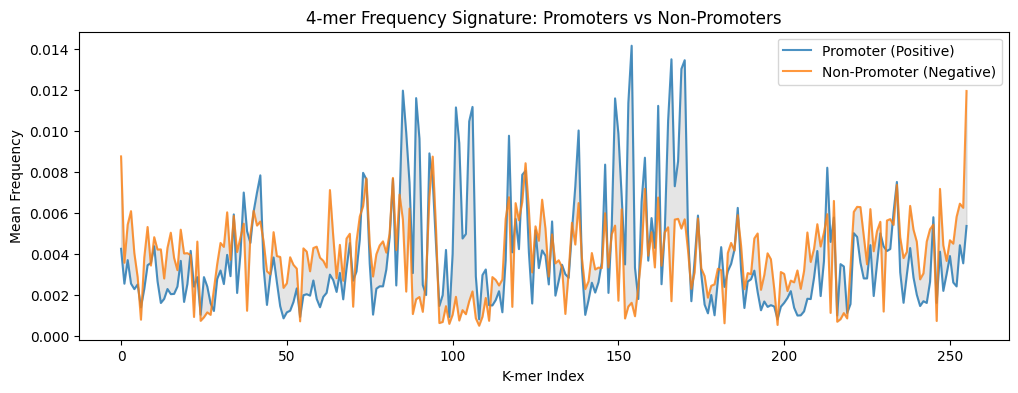

In [6]:
# Compare mean K-mer frequencies across classes
pos_mask = (kmer_train.y == 1).flatten()
neg_mask = (kmer_train.y == 0).flatten()

pos_mean = kmer_train.X[pos_mask].mean(axis=0)
neg_mean = kmer_train.X[neg_mask].mean(axis=0)

plt.figure(figsize=(12, 4))
plt.plot(pos_mean, label="Promoter (Positive)", alpha=0.8)
plt.plot(neg_mean, label="Non-Promoter (Negative)", alpha=0.8)
plt.fill_between(range(256), pos_mean, neg_mean, color='gray', alpha=0.2)
plt.title("4-mer Frequency Signature: Promoters vs Non-Promoters")
plt.xlabel("K-mer Index")
plt.ylabel("Mean Frequency")
plt.legend()
plt.show()


## Section 4: Baseline Modeling with Random Forest
We use DeepChem's `SklearnModel` wrapper to train a quick baseline on our K-mer features.


In [7]:
# Initialize and train
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
model = dc.models.SklearnModel(rf)
model.fit(kmer_train)

# Evaluate using DeepChem's ROC-AUC metric
metric = dc.metrics.Metric(dc.metrics.roc_auc_score, mode="classification")
kmer_test = kmer_datasets[-1]
test_score = model.evaluate(kmer_test, [metric])

print(f"Baseline Test ROC-AUC: {test_score['roc_auc_score']:.4f}")


Baseline Test ROC-AUC: 0.9803


## Section 5: Foundation Models (DNABERT-2)
Finally, we scale up to a Transformer-based foundation model. DNABERT-2 is pre-trained on massive genomic corpora and can be fine-tuned for specific tasks.


In [8]:
from genomics.dnabert2 import DNABERT2Model
import deepchem as dc

metric = dc.metrics.Metric(dc.metrics.roc_auc_score, mode="classification")

model_dir = os.path.join(os.getcwd(), "dnabert2_checkpoints")
os.makedirs(model_dir, exist_ok=True)

bert_model = DNABERT2Model(
    task="classification",
    n_tasks=1,
    model_dir=model_dir,
    batch_size=4,
    max_seq_length=128,
    learning_rate=2e-5,
)

bert_model.fit(train, nb_epoch=1)
bert_score = bert_model.evaluate(test, [metric], n_classes=2)
print(f"DNABERT-2 Test ROC-AUC: {bert_score[metric.name]:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

configuration_bert.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- configuration_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

...

flash_attn_triton.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- flash_attn_triton.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- bert_layers.py
- bert_padding.py
- flash_attn_triton.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/468M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/deepchem/models/torch_models/torch_model.py:391: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  avg_loss = float(avg_loss) / averaged_batches


DNABERT-2 Test ROC-AUC: 0.9663


In [10]:
metrics = [
    dc.metrics.Metric(dc.metrics.roc_auc_score, mode="classification"),
]
scores = bert_model.evaluate(test, metrics, n_classes=2)
for name, value in scores.items():
    print(f"  {name}: {value:.4f}")

  roc_auc_score: 0.9663


In [11]:
import numpy as np
from sklearn.metrics import recall_score

# Raw predictions: shape (n, 1, 2) — logits or probs
preds = bert_model.predict(test)

# Class indices: (n,) with values 0 or 1
y_pred = np.argmax(preds, axis=-1).squeeze()

# Labels: (n,) — match loader's (n, 1) layout
y_true = test.y.squeeze()

recall = recall_score(y_true, y_pred)
print(f"Recall: {recall:.4f}")

Recall: 0.9213


## References

- **Genomic Benchmarks**: [ML-Bioinfo-CEITEC/genomic_benchmarks](https://github.com/ML-Bioinfo-CEITEC/genomic_benchmarks)
- **DNABERT-2**: Zhou, Z. et al. DNABERT-2: Efficient Foundation Model and Benchmark for Multi-Species Genome. arXiv:2306.15006 (2023)
- **DeepChem**: [deepchem/deepchem](https://github.com/deepchem/deepchem)